In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# loading dataset
data = load_breast_cancer()
X, y = data.data, data.target
X.shape, y.shape

In [ ]:
# Using iloc (integer location indexing)
X[0]  # or
X[0, :]  # explicitly get all columns of row 0

# Using numpy
np.take(X, 0, axis=0)

# Using advanced indexing
X[[0]]  # returns 2D array instead of 1D

In [ ]:
y[0]

In [ ]:
data.target_names

In [ ]:
# splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# data standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# defining model
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)), # Input
    layers.Dense(32, activation="relu"), # layer 1 with 32 neurons
    layers.Dropout(0.3), # 30% of neurons in the previous layer are randomly turned off during each training step
    layers.Dense(16, activation="relu"), # layer 2 with 16 neurons
    layers.Dense(1, activation="sigmoid")  # layer 3 with 1 neuron
])

In [ ]:
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# plotting accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# plotting loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

#### Assignment
- Train a feed-forward neural network to solve a multi-class classification task. You can use a dataset of your choice from scikit-learn or kaggle. Use the ``Weights and Biases`` Python library for visualization during model training, and take screenshots of your dashboard. Compute relevant performance metrics and save your model.


In [ ]:
# Dataset and Weights and Biases import

from sklearn.datasets import fetch_covtype
import wandb

from dotenv import load_dotenv
import os

load_dotenv()

import wandb
wandb.login(key=os.getenv("WANDB_API_KEY"))

wandb.init(project="classification-nn")

data = fetch_covtype

X, y = fetch_covtype(return_X_y=True)

#Since the dataset is soo big we scale it down
X = X[:50000] 
y= y[:50000]

# splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# data standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


wandb.init(project ="classification-nn")


In [ ]:
# Model definition
model_nn = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(8, activation='softmax')  # 7 classes
])

In [ ]:
# Model compilation
model_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Train with W&B logging

from wandb.integration.keras import WandbMetricsLogger

model_nn.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    callbacks=[WandbMetricsLogger()]
)

In [ ]:
# Metrics of performance

#overall accuracy
test_loss, test_acc = model_nn.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}") 

#Classification report
from sklearn.metrics import accuracy_score, classification_report

preds = model_nn.predict(X_test)
preds = preds.argmax(axis=1)

print(classification_report(y_test, preds))

In [ ]:
# Visualization of performance metrics

from sklearn.metrics import confusion_matrix
import seaborn as sns

# local visualization
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# log to wandb
wandb.log({
    "confusion_matrix": wandb.plot.confusion_matrix(
        probs=None,
        y_true=y_test,
        preds=preds,
        class_names=[str(i) for i in range(10)]
    )
})

wandb.finish()

In [ ]:
model_nn.save("classification_model.keras")

### Screenshot of W&B graphs

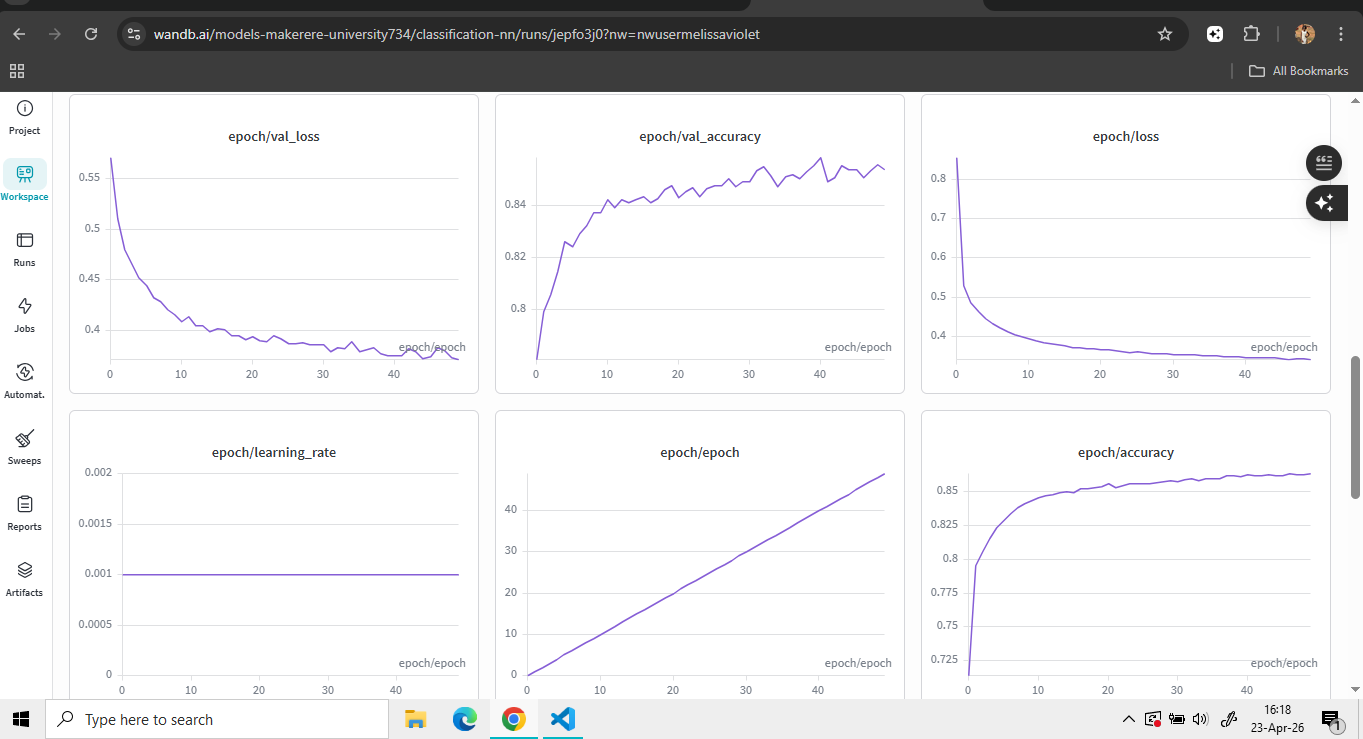

- Use the PyTorch Python library to train a feedforward neural network to solve a regression task. You can use a dataset of your choice. Implement checkpointing and earlystopping. Compute relevant performance metrics and save your best model

In [ ]:
# Dataset 

from sklearn.datasets import fetch_california_housing

cali_data = fetch_california_housing()
X, y = cali_data.data, cali_data.target * 100_000

# splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train ,test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test) 


In [ ]:
# Each split to PyTorch tensors

import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [ ]:
# Creat DataLoaders

from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

In [ ]:
# Define Model

import torch.nn as nn

class Net(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

model = Net(X_train.shape[1])

In [ ]:
# Loss + optimizer

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Early stopping + checkpoint setup

best_val_loss = float('inf')
patience = 5
counter = 0

In [ ]:
# Training Loop 

for epoch in range(50):

    # TRAINING
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        preds = model(xb)
        loss = criterion(preds, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()

    print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), "best_model.pt")  # checkpoint
        print("✅ Model saved!")

    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping triggered")
        break



In [ ]:
# Evaluate Model

from sklearn.metrics import mean_squared_error, r2_score

model.load_state_dict(torch.load("best_model.pt"))
model.eval()

with torch.no_grad():
    preds = model(X_test).numpy()
    y_true = y_test.numpy()

print("MSE:", mean_squared_error(y_true, preds))
print("R2:", r2_score(y_true, preds))